In [ ]:
# ============================================
# CELL 1: LIBRARY IMPORTS
# ============================================
# Importing essential libraries for data manipulation, visualization, and machine learning
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler  # Added for Feature Scaling
from sklearn.metrics import silhouette_score     # Added for Mathematical Validation

# Set visualization style
sns.set_theme(style="whitegrid")

# Customer Segmentation Project using KMeans Clustering
## Part 1: Data Loading and Exploratory Data Analysis (EDA)
In this section, we load the Mall Customers dataset and explore its statistical properties and distributions.

In [ ]:
# ==========================================
# CELL 2: DATA LOADING
# ==========================================
# Load the dataset into a pandas DataFrame
df = pd.read_csv("Mall_Customers.csv")

# Display the first 5 rows to understand the structure
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# ==========================================
# CELL 3: STATISTICAL SUMMARY
# ==========================================
# Check basic stats: mean, standard deviation, min, max, and quartiles
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


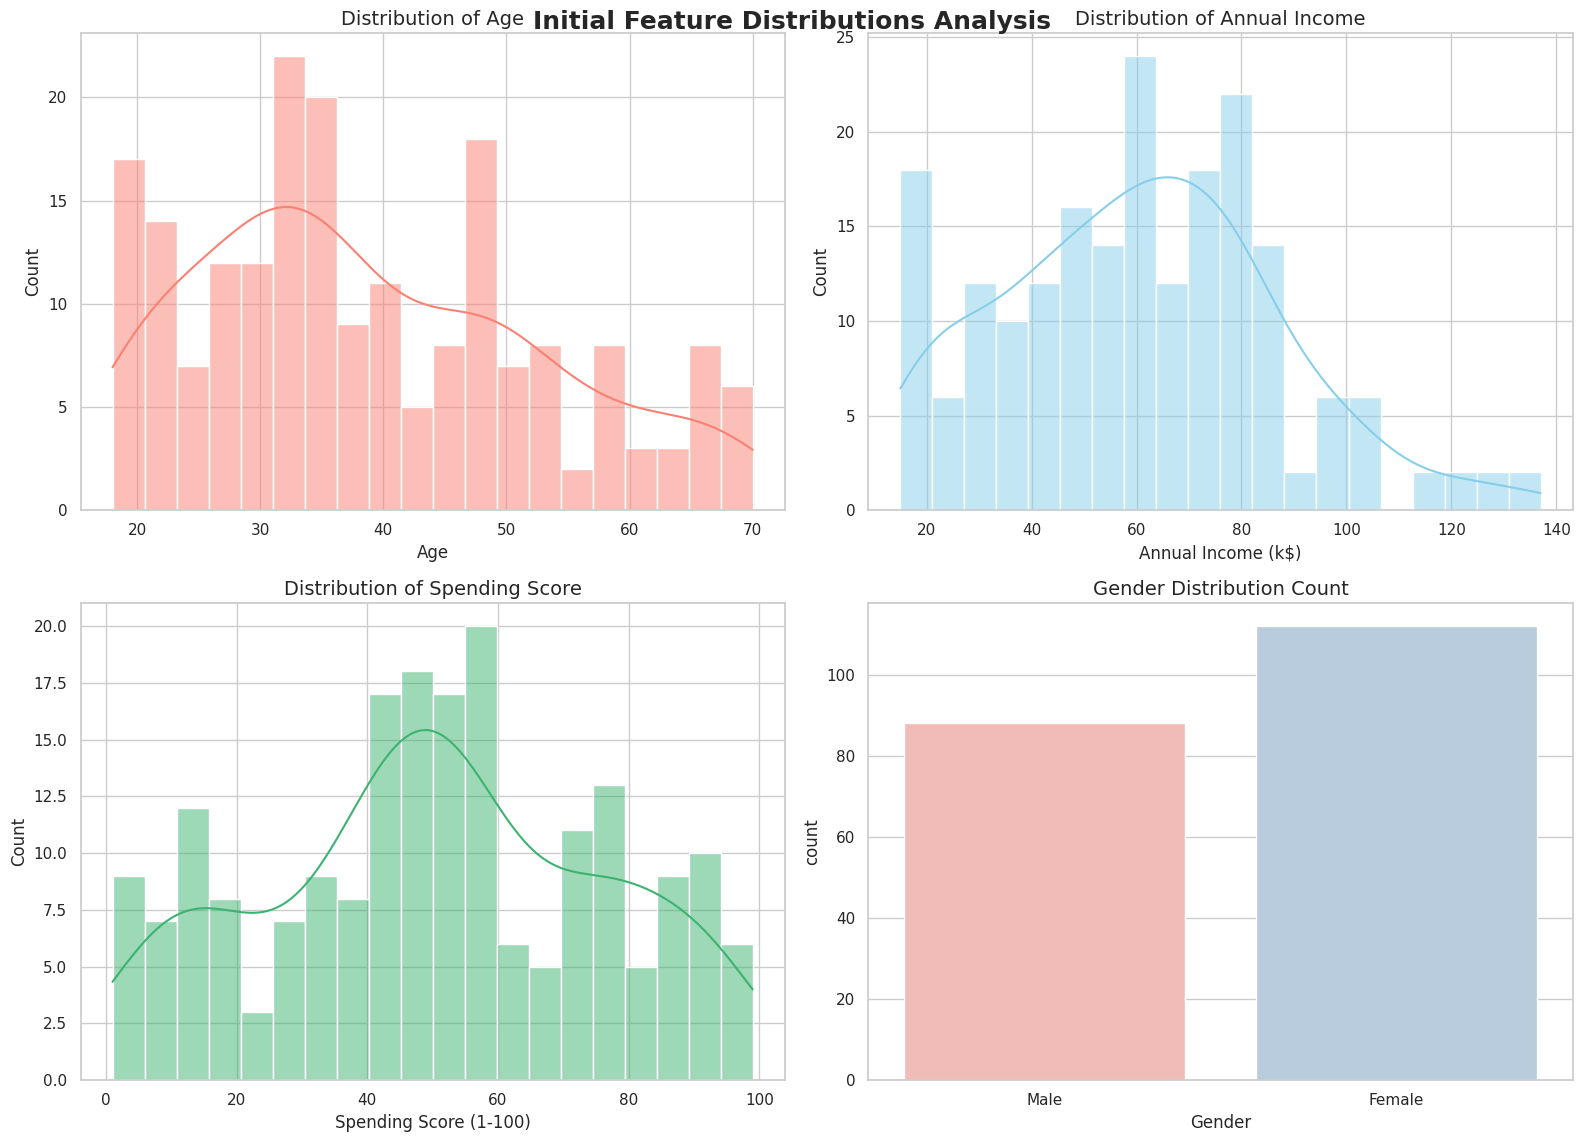

In [ ]:
# =========================================================================
# CELL 4: INITIAL MULTIPLE PLOTS (UNIVARIATE ANALYSIS WITH 2x2 SUBPLOTS)
# =========================================================================
# Grouping all initial distributions into a clean 2x2 grid layout
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of Age
sns.histplot(df['Age'], kde=True, color='salmon', ax=axes[0, 0], bins=20)
axes[0, 0].set_title('Distribution of Age', fontsize=14)

# 2. Distribution of Annual Income
sns.histplot(df['Annual Income (k$)'], kde=True, color='skyblue', ax=axes[0, 1], bins=20)
axes[0, 1].set_title('Distribution of Annual Income', fontsize=14)

# 3. Distribution of Spending Score - CORRETTO: Usato 'mediumseagreen' (o il codice HEX '#2ecc71')
sns.histplot(df['Spending Score (1-100)'], kde=True, color='mediumseagreen', ax=axes[1, 0], bins=20)
axes[1, 0].set_title('Distribution of Spending Score', fontsize=14)

# 4. Count of Gender - CORRETTO: Aggiunto 'hue' e rimosso il warning sulla palette
sns.countplot(data=df, x='Gender', hue='Gender', palette='Pastel1', ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Gender Distribution Count', fontsize=14)

plt.suptitle('Initial Feature Distributions Analysis', fontsize=18, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()


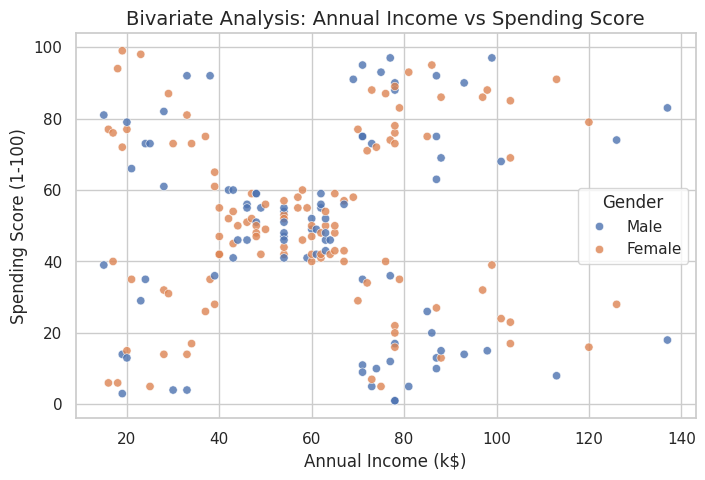

In [ ]:
# ==========================================
# CELL 5: BIVARIATE ANALYSIS
# ==========================================
plt.figure(figsize=(8, 5))

# Visualizing the direct relationship between Annual Income and Spending Score
# This scatter plot hints at the natural presence of 5 distinct spatial groups
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', alpha=0.8)

plt.title("Bivariate Analysis: Annual Income vs Spending Score", fontsize=14)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

## Part 2: Data Preprocessing and Feature Scaling
KMeans relies heavily on calculating Euclidean distances between points. Therefore, features with different scales can disproportionately influence the algorithm.
We will extract our target features (`Annual Income` and `Spending Score`) and standardize them to ensure equal weight during modeling.

In [ ]:
# =========================================================================
# CELL 6: FEATURE SELECTION, SCALING & CENTROID CALCULATION
# =========================================================================
from sklearn.preprocessing import StandardScaler

# Extracting target features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# ADDED: Standardizing features for distance-based algorithm accuracy
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Training the final model with K=5 on scaled data
optimal_k = 5
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Spending and Income Cluster'] = final_kmeans.fit_predict(X_scaled)

# ADDED: Extracting mathematical centroids and applying inverse transformation
# This converts coordinates from scaled values back to real-world metrics (Income & Score)
scaled_centroids = final_kmeans.cluster_centers_
original_centroids = scaler.inverse_transform(scaled_centroids)

# Storing centroids in a DataFrame for easier plotting
centroids_df = pd.DataFrame(original_centroids, columns=['Annual Income (k$)', 'Spending Score (1-100)'])

print("--- Real-World Coordinates of Cluster Centroids ---")
print(centroids_df)

--- Real-World Coordinates of Cluster Centroids ---
   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043


## Part 3: Finding the Optimal Number of Clusters (K)
To avoid randomly guessing the value of K, we implement two mathematical benchmarks:
1. **The Elbow Method (Inertia):** Looking for the point where the Within-Cluster Sum of Squares (WCSS) starts decreasing linearly.
2. **Silhouette Score:** Measuring how similar an object is to its own cluster compared to other clusters (closer to 1 is optimal).

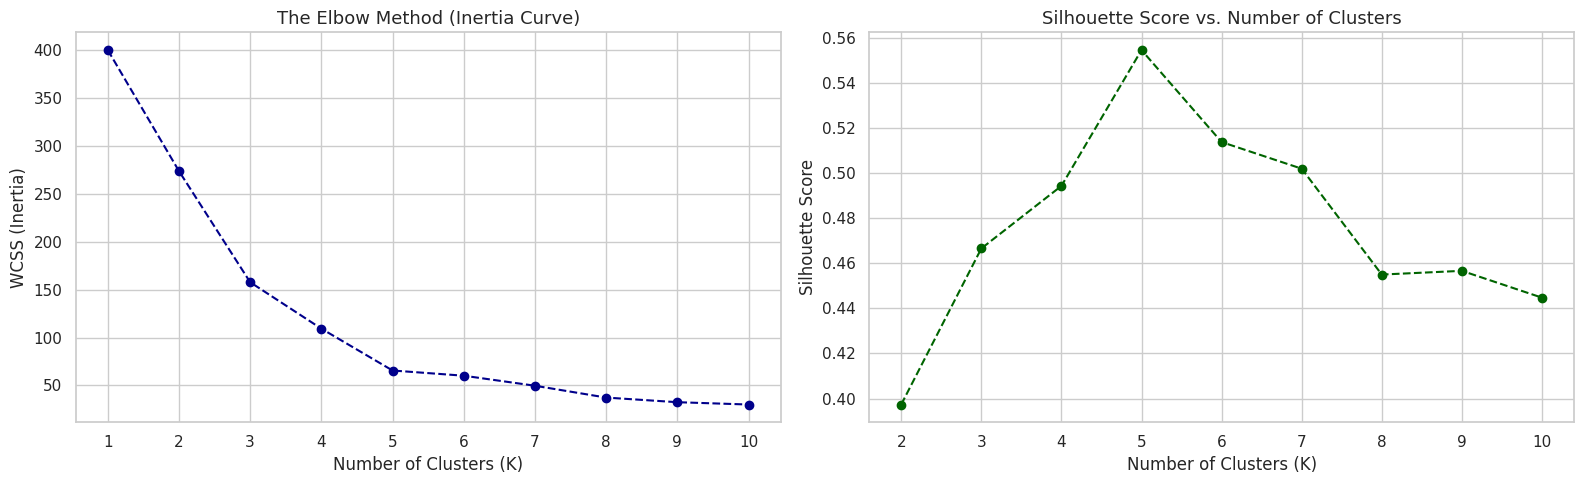

In [ ]:
# ==========================================
# CELL 7: ELBOW METHOD & SILHOUETTE SCORE
# ==========================================
wcss = []
sil_scores = []
k_range = range(2, 11)

# Calculate WCSS for K=1 to K=10 for the Elbow curve
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Calculate Silhouette Score for K=2 to K=10
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plotting both metrics side-by-side for comparison
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Elbow Method
ax[0].plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkblue')
ax[0].set_title('The Elbow Method (Inertia Curve)', fontsize=13)
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('WCSS (Inertia)')
ax[0].set_xticks(range(1, 11))

# Plot 2: Silhouette Scores
ax[1].plot(k_range, sil_scores, marker='o', linestyle='--', color='darkgreen')
ax[1].set_title('Silhouette Score vs. Number of Clusters', fontsize=13)
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

## Part 4: Final Model Training and Visualisation
Based on the Elbow curve 'elbow' break at K=5 and the highest peak achieved in the Silhouette score, **K=5** is definitively verified as the optimal number of clusters. Let's fit the final model.

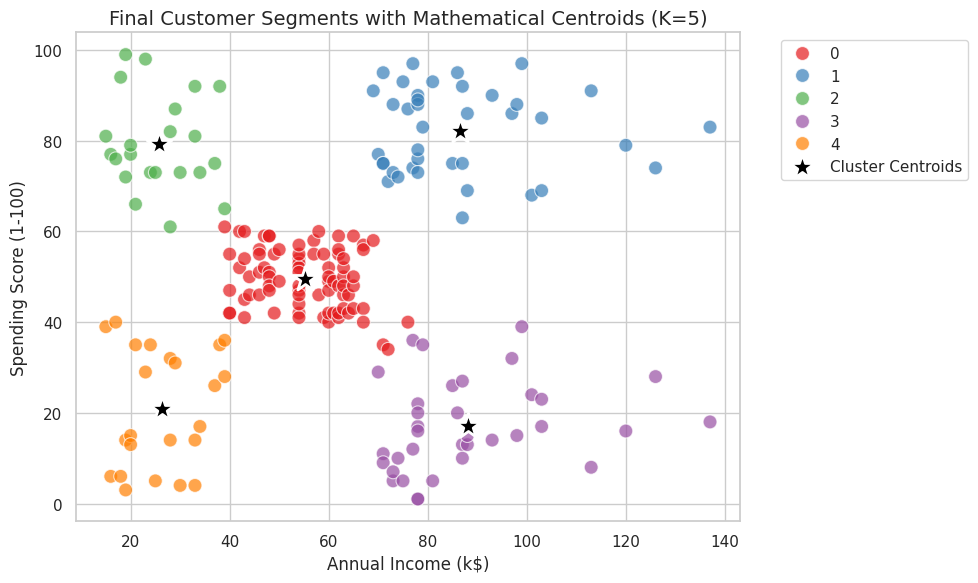

In [ ]:
# =========================================================================
# CELL 8: 2D CLUSTER VISUALIZATION WITH REAL-WORLD CENTROIDS
# =========================================================================
plt.figure(figsize=(10, 6))

# Plotting the customer data points colored by cluster
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Spending and Income Cluster', palette='Set1', s=100, alpha=0.7)

# ADDED: Superimposing the exact mathematical cluster centers (Black 'X')
plt.scatter(
    x=centroids_df['Annual Income (k$)'],
    y=centroids_df['Spending Score (1-100)'],
    s=350,              # Large size to stand out
    c='black',          # Solid black color
    marker='*',         # 'X' shape
    edgecolors='white', # White border for contrast
    linewidths=2,
    label='Cluster Centroids'
)

plt.title('Final Customer Segments with Mathematical Centroids (K=5)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Part 5: Cluster Profiling & Business Insights
Now we analyze the demographic and behavioral trends within each cluster to build data-driven marketing personas.

In [ ]:
# ==========================================
# CELL 10: DEMOGRAPHIC PROFILING
# ==========================================
# Cross-tabulation to find Gender distribution within each cluster (%)
gender_profile = pd.crosstab(df['Spending and Income Cluster'], df['Gender'], normalize='index') * 100
print("--- Gender Distribution per Cluster (%) ---")
print(gender_profile.round(2))

print("\n" + "="*50 + "\n")

# Aggregating mean values of numerical metrics per cluster
cluster_metrics_mean = df.groupby('Spending and Income Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("--- Numerical Feature Averages per Cluster ---")
print(cluster_metrics_mean.round(2))

--- Gender Distribution per Cluster (%) ---
Gender                       Female   Male
Spending and Income Cluster               
0                             59.26  40.74
1                             53.85  46.15
2                             59.09  40.91
3                             45.71  54.29
4                             60.87  39.13


--- Numerical Feature Averages per Cluster ---
                               Age  Annual Income (k$)  Spending Score (1-100)
Spending and Income Cluster                                                   
0                            42.72               55.30                   49.52
1                            32.69               86.54                   82.13
2                            25.27               25.73                   79.36
3                            41.11               88.20                   17.11
4                            45.22               26.30                   20.91


## Part 6: Multivariate Analysis (Cluster Evaluation)
To wrap up our analysis, we perform multivariate plotting. This allows us to observe how our segments separate across all available numerical fields simultaneously (including Age, which wasn't used to build the clusters).

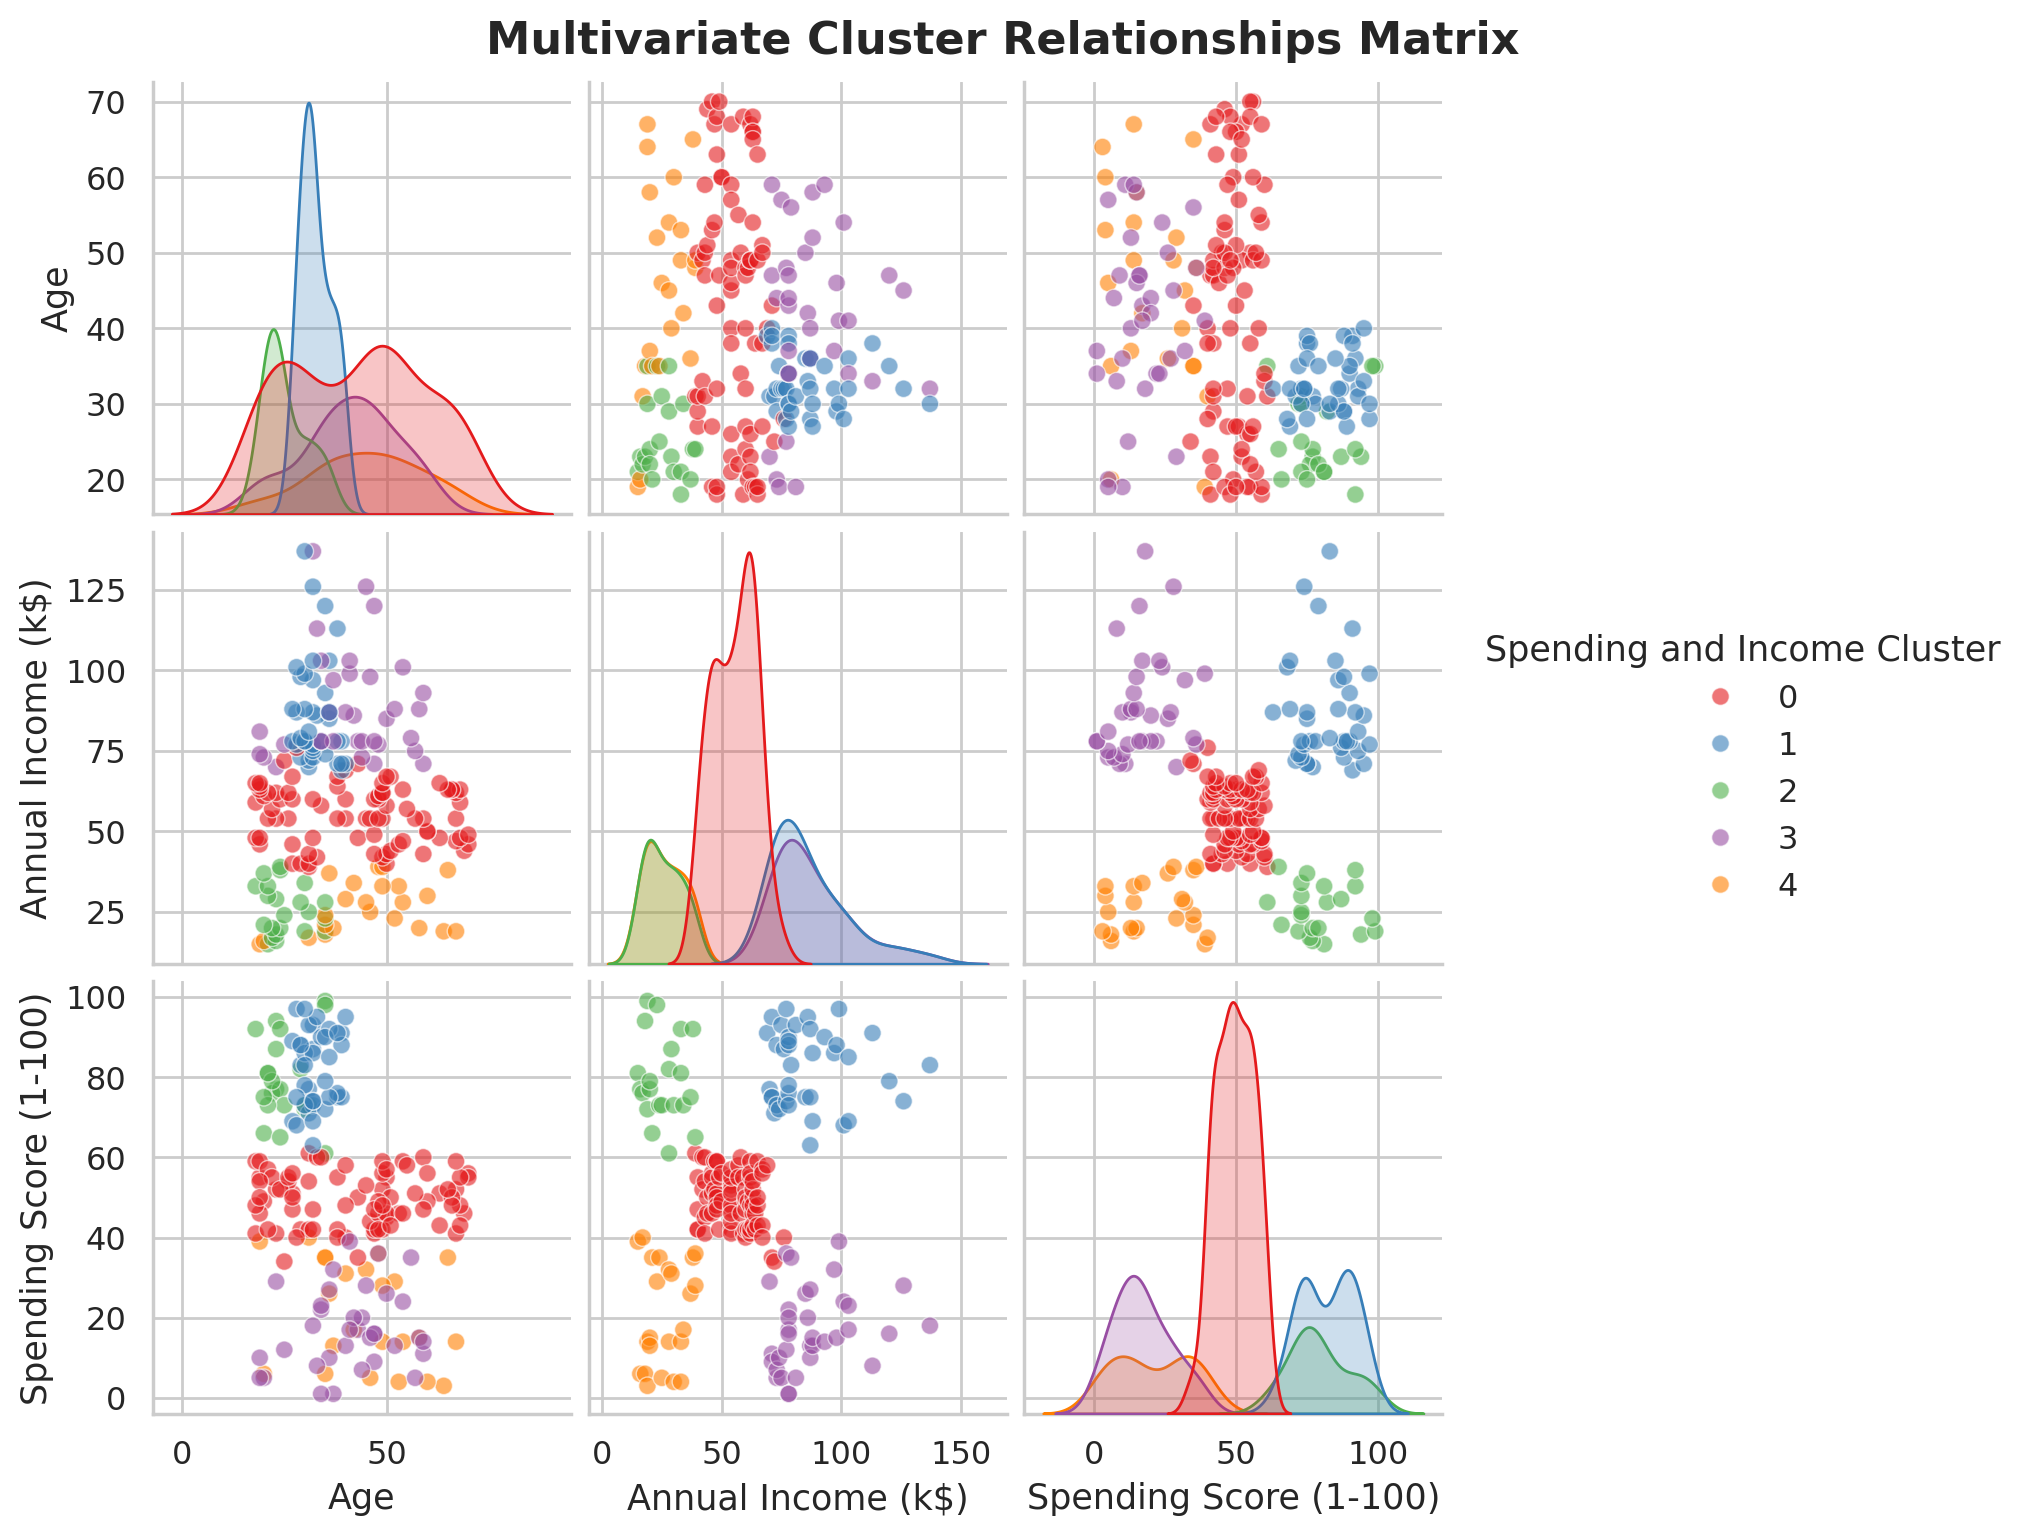

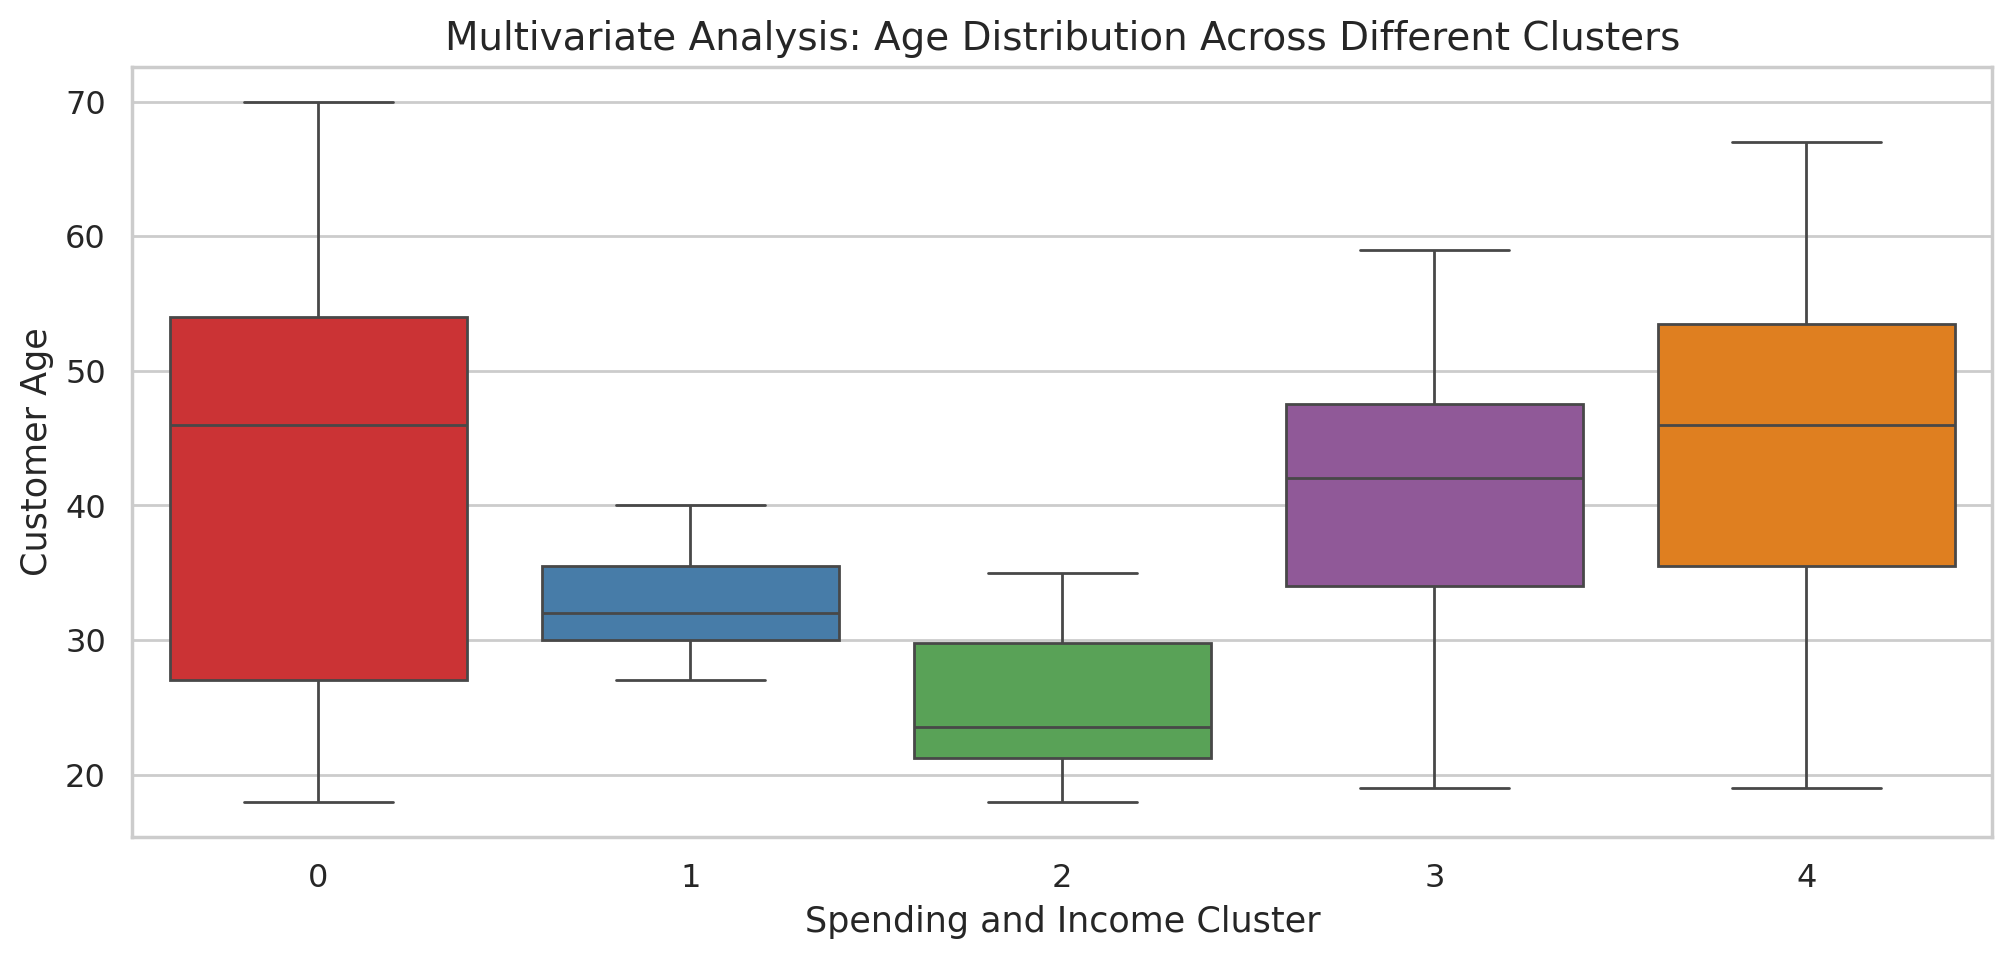

In [ ]:
# =========================================================================
# CELL 11: MULTIVARIATE ANALYSIS (PAIRPLOT & BOXPLOTS)
# =========================================================================
# 1. Pairwise scatter matrix showing cross-features interactions, grouped by cluster color
multivariate_grid = sns.pairplot(
    data=df,
    vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
    hue='Spending and Income Cluster',
    palette='Set1',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)
multivariate_grid.fig.suptitle('Multivariate Cluster Relationships Matrix', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# 2. Multivariate Boxplot to evaluate the hidden role of Age across the behavioral clusters
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Spending and Income Cluster', y='Age', palette='Set1')
plt.title('Multivariate Analysis: Age Distribution Across Different Clusters', fontsize=14)
plt.xlabel('Spending and Income Cluster')
plt.ylabel('Customer Age')
plt.show()

### Summary of Strategic Marketing Personas:
* **Cluster 0:** *High Income, Low Spending Score.* -> **"Careful/Frugal Customers"**. High purchasing capacity but low engagement. Target them with exclusive premium loyalty programs.
* **Cluster 1:** *Average Income, Average Spending Score.* -> **"Standard/Middle Ground"**. Consistent mall visitors. Keep them engaged with regular standard promotions.
* **Cluster 2:** *High Income, High Spending Score.* -> **"Target/VIP Customers"**. High income and high spending. This is the prime cluster for new product launches and high-ticket marketing campaigns.
* **Cluster 3:** *Low Income, High Spending Score.* -> **"Impulsive Shoppers"**. Low income but high spending habits. Can be targeted with frequent flash sales or discount pop-ups.
* **Cluster 4:** *Low Income, Low Spending Score.* -> **"Sensible/Sensible Spenders"**. Low earnings and highly conservative spending. Budget-friendly or value-for-money options work best here.